# Loan Approval Prediction

In [17]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from src.evaluate import evaluate_classification_metrics

In [3]:
dataset_path = "../dataset/hdfc_loan_dataset_full_enriched.csv"

df = pd.read_csv(dataset_path)
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   str    
 1   Bank                         1000 non-null   str    
 2   Customer_Name                1000 non-null   str    
 3   Gender                       1000 non-null   str    
 4   Married                      1000 non-null   str    
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   str    
 7   Employment_Status            1000 non-null   str    
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area                1

In [5]:
df.isnull().sum()

Loan_ID                          0
Bank                             0
Customer_Name                    0
Gender                           0
Married                          0
Dependents                       0
Education                        0
Employment_Status                0
Applicant_Income                 0
Coapplicant_Income               0
Loan_Amount                      0
Loan_Term_Months                 0
Credit_History                   0
Property_Area                    0
Age                              0
Loan_Status                      0
CIBIL_Score                      0
Annual_Household_Income          0
Debt_to_Income_Ratio             0
Purpose_of_Loan                  0
Existing_EMIs                    0
Number_of_Previous_Loans         0
Default_History_Count            0
Employment_Length_Years          0
Business_Type                  799
Asset_Value                      0
Guarantor                        0
Co-signer_Relationship         234
Monthly_Expense     

In [6]:
# Encode Target Variable
label_encoder = LabelEncoder()
df['Loan_Status'] = label_encoder.fit_transform(df['Loan_Status'])

In [7]:
# Feature Selection
features = [
    'Applicant_Income',
    'Coapplicant_Income',
    'Loan_Amount',
    'Credit_History',
    'CIBIL_Score',
    'Employment_Status',
    'Existing_EMIs',
    'Debt_to_Income_Ratio',
    'Education',
    'Property_Area'
]

X = df[features]
y = df['Loan_Status']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# Separate numeric and categorical columns
numeric_cols = [
    'Applicant_Income',
    'Coapplicant_Income',
    'Loan_Amount',
    'Credit_History',
    'CIBIL_Score',
    'Existing_EMIs',
    'Debt_to_Income_Ratio'
]

categorical_cols = [
    'Employment_Status',
    'Education',
    'Property_Area'
]

In [10]:
# Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'encoder',
        OneHotEncoder(handle_unknown='ignore')
    )
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

## Logistic Regression

Best Logistic Regression Parameters
{'model__C': 10, 'model__solver': 'liblinear'}
Logistic Regression
Accuracy  : 0.81
Precision : 0.746031746031746
Recall    : 0.6811594202898551
F1 Score  : 0.7121212121212122
ROC-AUC   : 0.8684589003208321

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       131
           1       0.75      0.68      0.71        69

    accuracy                           0.81       200
   macro avg       0.79      0.78      0.79       200
weighted avg       0.81      0.81      0.81       200



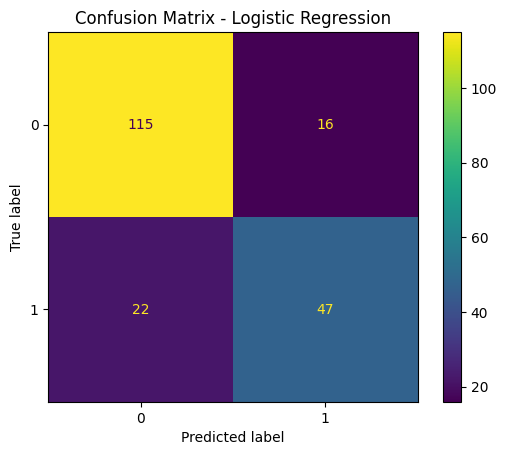

In [11]:
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model', 
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

log_params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

log_grid = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_params,
    cv=StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=43
    ),
    scoring='accuracy',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

best_log_model = log_grid.best_estimator_

print("Best Logistic Regression Parameters")
print(log_grid.best_params_)

results = []
results.append(
    evaluate_classification_metrics(
        "Logistic Regression",
        best_log_model,
        X_test,
        y_test
    )
)


## Decision Tree

Best Decision Tree Parameters
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Decision Tree
Accuracy  : 0.795
Precision : 0.7
Recall    : 0.7101449275362319
F1 Score  : 0.7050359712230215
ROC-AUC   : 0.8276911162739241

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       131
           1       0.70      0.71      0.71        69

    accuracy                           0.80       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.80      0.80      0.80       200



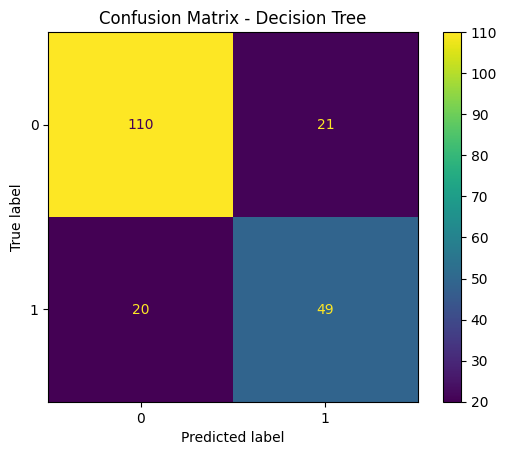

In [12]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        DecisionTreeClassifier(
            random_state=42
        )
    )
])


dt_params = {
    'model__max_depth': [3, 5, 10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}


dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring='accuracy',
    n_jobs=-1
)


dt_grid.fit(X_train, y_train)

best_dt_model = dt_grid.best_estimator_

print("Best Decision Tree Parameters")
print(dt_grid.best_params_)

results.append(
    evaluate_classification_metrics(
        "Decision Tree",
        best_dt_model,
        X_test,
        y_test
    )
)

## Random Forest

Best Random Forest Parameters
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Random Forest
Accuracy  : 0.845
Precision : 0.8166666666666667
Recall    : 0.7101449275362319
F1 Score  : 0.7596899224806202
ROC-AUC   : 0.9176900099568537

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       131
           1       0.82      0.71      0.76        69

    accuracy                           0.84       200
   macro avg       0.84      0.81      0.82       200
weighted avg       0.84      0.84      0.84       200



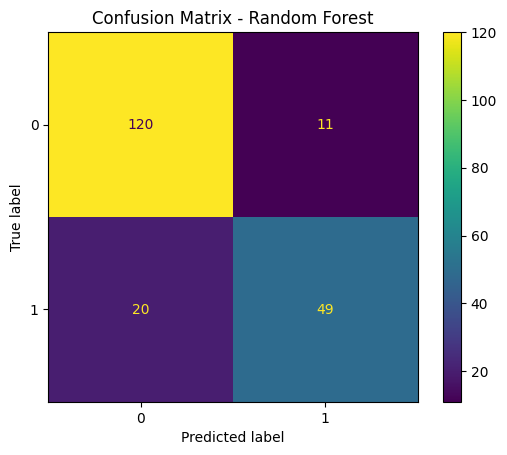

In [13]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        RandomForestClassifier(
            random_state=42
        )
    )
])

rf_params = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring='accuracy',
    n_jobs=-1
)


rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_

print("Best Random Forest Parameters")
print(rf_grid.best_params_)

results.append(
    evaluate_classification_metrics(
        "Random Forest",
        best_rf_model,
        X_test,
        y_test
    )
)


In [14]:
# Compare performance
results_df = pd.DataFrame(results)

print("Model Comparison")
print(results_df)

Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression     0.810   0.746032  0.681159  0.712121  0.868459
1        Decision Tree     0.795   0.700000  0.710145  0.705036  0.827691
2        Random Forest     0.845   0.816667  0.710145  0.759690  0.917690


In [15]:
best_model_index = results_df['Accuracy'].idxmax()

best_model_name = results_df.loc[
    best_model_index,
    'Model'
]

print(f"\nBest Model: {best_model_name}")


if best_model_name == 'Logistic Regression':
    final_model = best_log_model

elif best_model_name == 'Decision Tree':
    final_model = best_dt_model

else:
    final_model = best_rf_model



Best Model: Random Forest


In [16]:
MODEL_PATH = "../models/loan_approval_pipeline.pkl"

joblib.dump(final_model, MODEL_PATH)

print(f"\nModel saved successfully at: {MODEL_PATH}")


Model saved successfully at: ../models/loan_approval_pipeline.pkl
